In [ ]:
# Data collection command:
# `python comet_download.py --project=generalization-paper-v4-ns-grad-descent-hyper-sweep --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
save_path = 'figures/'
config_data_path = 'data/generalization-paper-v4-ns-grad-descent-hyper-sweep_params.csv'
run_data_path = 'data/generalization-paper-v4-ns-grad-descent-hyper-sweep_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

{k: len(v) for k, v in config_dfs.items()}

{'sgd': 35,
 'sgd_layerwise_step_size': 210,
 'perfect_features_autostep': 180,
 'autostep': 150,
 'autostep_loss_grads': 80}

In [4]:
print("_____Best Hyperparameter Configurations_____")
best_config_dfs, best_run_dfs, best_ablation_values = get_best_ablation_values(config_dfs, run_dfs)

_____Best Hyperparameter Configurations_____

=== sgd ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-14


=== sgd_layerwise_step_size ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-14
  Best representation_optimizer|learning_rate=2**8


=== perfect_features_autostep ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|meta_learning_rate=2**-11
  Best optimizer|learning_rate=2**-8


=== autostep ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|meta_learning_rate=2**-4
  Best optimizer|learning_rate=2**6


=== autostep_loss_grads ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|meta_learning_rate=2**-4
  Best optimizer|learning_rate=2**4



In [5]:
print("_____Best Hyperparameter Configurations_____")
best_feat_config_dfs, best_feat_run_dfs, best_feat_ablation_values = get_best_ablation_values(
    config_dfs, run_dfs,
    metric_col = 'feature_match/average_best_match_normalized_distance',
    metric_direction = 'max',
)

_____Best Hyperparameter Configurations_____

=== sgd ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-12


=== sgd_layerwise_step_size ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-22
  Best representation_optimizer|learning_rate=2**-2


=== perfect_features_autostep ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|meta_learning_rate=2**-11
  Best optimizer|learning_rate=2**-8


=== autostep ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|meta_learning_rate=2**-2
  Best optimizer|learning_rate=2**-2


=== autostep_loss_grads ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|meta_learning_rate=2**-2
  Best optimizer|learning_rate=2**4



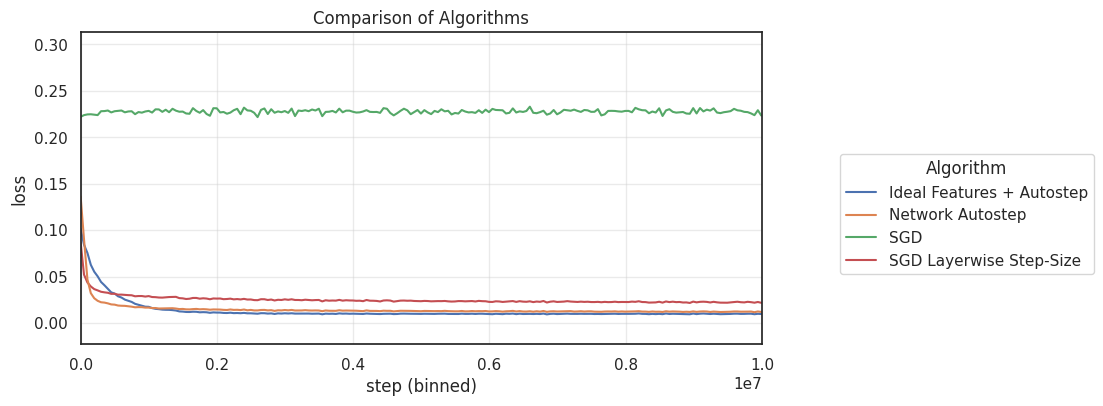

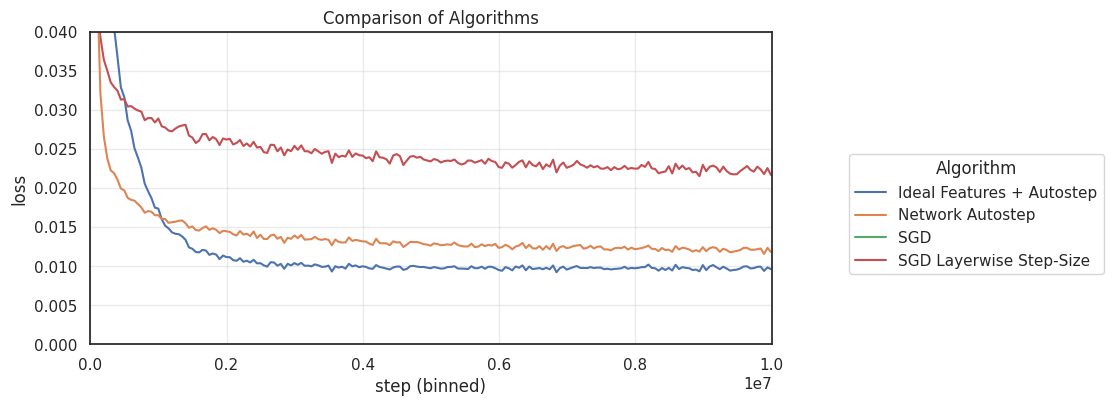

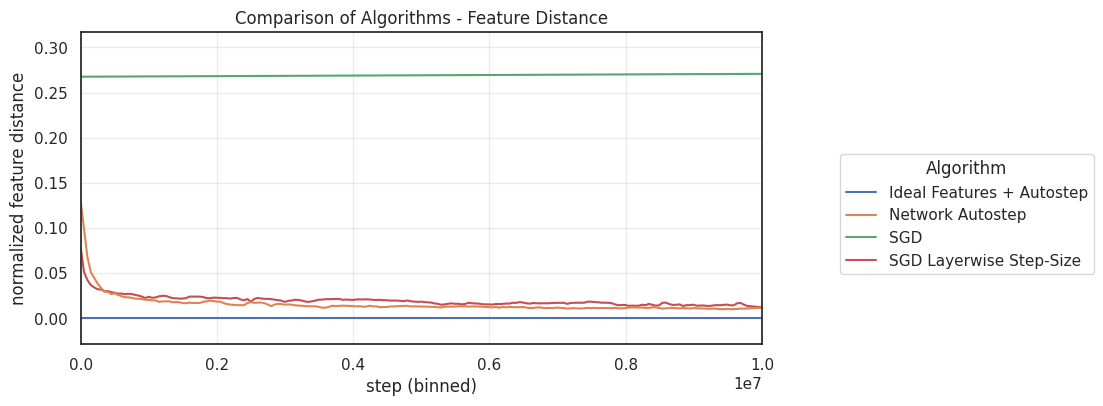

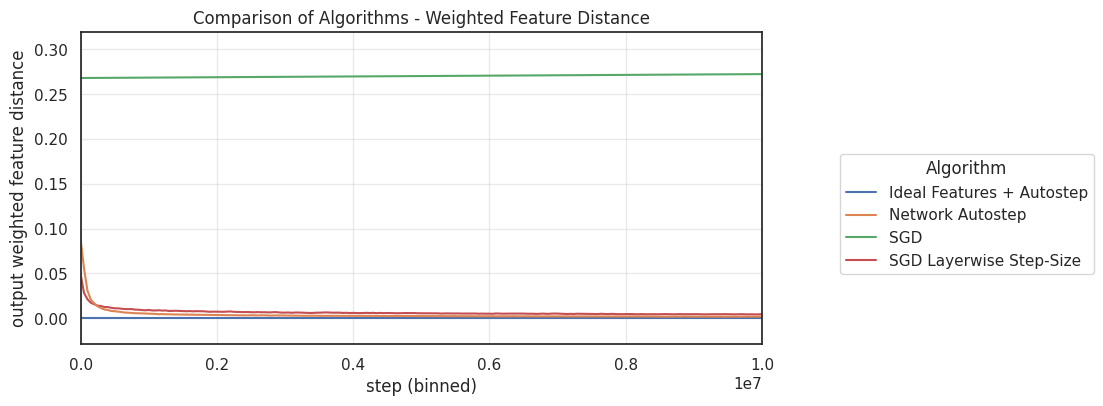

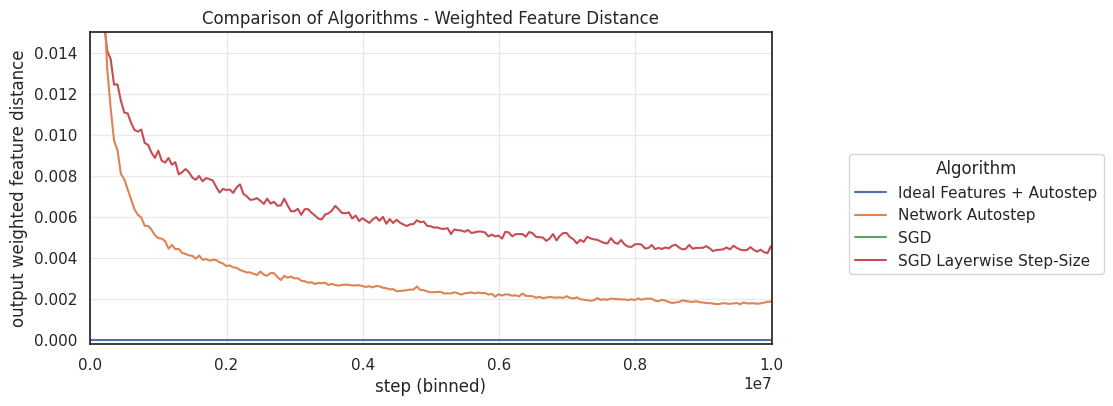

In [6]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(list(best_config_dfs.values()))

algo_map = {
    'sgd': 'SGD',
    'sgd_layerwise_step_size': 'SGD Layerwise Step-Size',
    'autostep': 'Network Autostep',
    # 'autostep_loss_grads': 'Autostep (Loss Grads)',
    'perfect_features_autostep': 'Ideal Features + Autostep', 
}

# Only keep rows whose sweep_name is in algo_map
combined_config_df = combined_config_df[combined_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)


plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.title('Comparison of Algorithms')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.ylim(0.0, 0.04)
plt.title('Comparison of Algorithms')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'normalized feature distance',
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.title('Comparison of Algorithms - Feature Distance')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/best_match_output_weighted_normalized_distance',
    y_label = 'output weighted feature distance',
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.title('Comparison of Algorithms - Weighted Feature Distance')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/best_match_output_weighted_normalized_distance',
    y_label = 'output weighted feature distance',
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.ylim(-0.0002, 0.015)
plt.title('Comparison of Algorithms - Weighted Feature Distance')
plt.show()